In [4]:
import numpy as np
from scipy import fft
from matplotlib import pyplot as plt


%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


In digital signal processing, *sampling* refers to the process of converting an analog signal into the digital domain.


Mathematically, a continuous signal $x(t)$ is sampled by a multiplication with an
impulse train $\delta_T(t)$ (also referred to as Dirac comb) of infitite length:
 

$$x[n] = x(t) \delta_T (t) = \sum\limits_{n=-\infty}^{\infty} x(n T) \delta (t-nT)$$

----

## Dirac Comb

The Dirac comb is a periodic function: 

$$
\delta(t-nT) = \delta(t-nT+T)
$$

The following plot shows a Dirac comb for $ T = 0.1$:

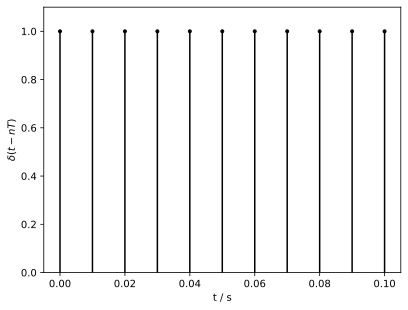

In [35]:
fig,ax = plt.subplots()

fs = 10                      # time distance between pulses
Fs = 1000                  # sampling frequency, used for discretizing the system

t = np.linspace(0, 1/fs, 101) # time range to consider

comb = np.zeros_like(t)
comb[::int(T)] = 2     # Comb becomes T every T*Fs samples
ax.stem(t, comb-1, 'k', markerfmt='k.', basefmt=" ")
ax.set_ylim([0,1.1])
ax.set_xlabel('t / s')
ax.set_ylabel('$\delta(t-nT)$');

This impulse train can be expressed as a Fourier series:

$$\delta_T = \frac{1}{T} \left[1 +2 \cos(\omega_s t) 2 \cos(2 \omega_s t) + \cdots \right]$$,  with $$\omega_s=\frac{2\pi}{T}$$

$$\delta_T = \frac{1}{T}  + \sum \left( \frac{2}{T} \cos(n \omega_s t) \right)$$

----

## Fourier Transform of the Dirac Comb

The Fourier transform of a time-domain impulse train is 
a frequency-domain impulse train:

$$\mathcal{F}(\delta_T) = \int_{-\infty}^{\infty} \delta(t-nT) e^{-j k \omega_0 t}dt$$

$$\mathcal{F}(\delta_T) = (\sum C_k e^{j k \omega_0 t})$$

$$\mathcal{F}(\delta_T) = \sum\limits_{m = -\infty}^{\infty} \delta(T f)$$

----

The Fourier transform of the Dirac comb in the time domain is a Dirac comb in the frequency domain with:

$$
\Delta f = \frac{1}{T}
$$



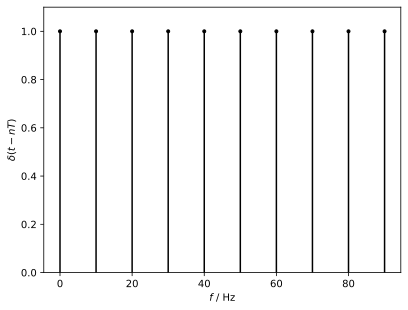

In [66]:
fig,ax = plt.subplots()

f = np.linspace(0, 90, 100) # time range to consider

comb = np.zeros_like(f)

comb[np.arange(0,100,11)] = 2  

ax.stem(f, comb-1, 'k', markerfmt='k.', basefmt=" ")
ax.set_ylim([0,1.1])
ax.set_xlabel('$f$ / Hz')
ax.set_ylabel('$\delta(t-nT)$');

----

## Fourier Transform of the Sampled Signal

According to the convolution theorem, a multiplication of two signals in the time domain is equivalent to a convolution in the frequency domain.
**The convolution with the Dirac comb in the frequency domain results in a periodic spectrum.**



$$X[i] = \frac{1}{T}  + \sum\limits_{n=-\infty}^{\infty}   X(\omega -n \omega_s)$$